In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.gru_trainer as gru_trainer
importlib.reload(gru_trainer)

<module 'src.gru_trainer' from 'c:\\Data_analysis\\Thesis\\src\\gru_trainer.py'>

In [2]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\15_min\df_BU_TotActPwr_Academy.parquet"
df = pd.read_parquet(path)

df = df.sort_index()
df.head()

,BU_TotActPwr_Academy,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,PV_WS_RelHum,dayofweek,is_weekend,hour,month,dayofmonth,...,BU_TotActPwr_Academy_roll_std_96,BU_TotActPwr_Academy_trend_1_4,BU_TotActPwr_Academy_trend_1_12,BU_TotActPwr_Academy_trend_1_96,BU_TotActPwr_Academy_trend_96_192,BU_TotActPwr_Academy_yesterday_mean,BU_TotActPwr_Academy_yesterday_max,BU_TotActPwr_Academy_yesterday_midday_max,BU_TotActPwr_Academy_yesterday_peak_time_step,BU_TotActPwr_Academy_lastweek_same_day_peak
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-22 00:00:00,5.36067,80.63333,126.00000,-4.30000,86.46667,2,0,0,10,22,...,2.481165,0.24000,0.20734,-0.73833,1.86300,7.011386,12.54667,11.58467,32.0,15.96933
2025-10-22 00:15:00,6.27833,80.20000,122.00000,-5.00000,86.40000,2,0,0,10,22,...,2.485274,0.03034,0.23300,0.00534,1.63700,7.011386,12.54667,11.58467,32.0,15.96933
2025-10-22 00:30:00,5.09133,79.83333,122.00000,-4.66667,87.00000,2,0,0,10,22,...,2.480612,1.16400,0.70866,0.83566,1.82267,7.011386,12.54667,11.58467,32.0,15.96933
2025-10-22 00:45:00,5.77000,79.40000,124.00000,-4.26667,87.80000,2,0,0,10,22,...,2.483211,-0.29834,-0.81934,-0.22167,1.27367,7.011386,12.54667,11.58467,32.0,15.96933
2025-10-22 01:00:00,5.05167,79.03333,125.33333,-4.33333,88.70000,2,0,1,10,22,...,2.480361,0.40933,-0.16200,0.48467,1.55966,7.011386,12.54667,11.58467,32.0,15.96933


In [3]:
target_col = "BU_TotActPwr_Academy"

feature_cols = [
    col for col in df.columns
    if col != target_col
]

len(feature_cols), feature_cols[:20]

(49,
 ['BA_Soc',
  'PV_WS_AirTemp',
  'PV_WS_Radiation',
  'PV_WS_RelHum',
  'dayofweek',
  'is_weekend',
  'hour',
  'month',
  'dayofmonth',
  'minute_of_day',
  'sin_tod',
  'cos_tod',
  'sin_dow',
  'cos_dow',
  'is_business_hours',
  'is_midday_peak_window',
  'is_midday_weekday_peak',
  'slot_5min',
  'BU_TotActPwr_Academy_lag_1',
  'BU_TotActPwr_Academy_lag_2'])

In [9]:
config = gru_trainer.GRUConfig(
    lookback=96,
    horizon=96,
    hidden_size=256,
    num_layers=4,
    dropout=0.3,
    batch_size=256,
    learning_rate=0.01,
    max_epochs=50,
    patience=8,
    train_ratio=0.80,
    val_ratio=0.15,
    test_ratio=0.05,
    seed=42,
)

results_df, history_df, pred_df = gru_trainer.run_gru_training_experiment(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    dataset_name="Imputed_data",
    feature_set_name="gru_all_features_v1",
    config=config,
)

results_df.T

Epoch 001 | train_loss=1.436975 | val_loss=1.389748
Epoch 002 | train_loss=0.420890 | val_loss=1.562005
Epoch 003 | train_loss=0.458517 | val_loss=1.295622
Epoch 004 | train_loss=0.443562 | val_loss=1.465327
Epoch 005 | train_loss=0.383404 | val_loss=1.697335
Epoch 006 | train_loss=0.377560 | val_loss=1.673920
Epoch 007 | train_loss=0.370017 | val_loss=1.544638
Epoch 008 | train_loss=0.407925 | val_loss=1.658935
Epoch 009 | train_loss=0.380458 | val_loss=1.521455
Epoch 010 | train_loss=0.307843 | val_loss=1.522415
Epoch 011 | train_loss=0.288105 | val_loss=1.268764
Epoch 012 | train_loss=0.233659 | val_loss=1.076248
Epoch 013 | train_loss=0.223597 | val_loss=0.995327
Epoch 014 | train_loss=0.224407 | val_loss=1.152120
Epoch 015 | train_loss=0.237135 | val_loss=1.148128
Epoch 016 | train_loss=0.295062 | val_loss=1.409092
Epoch 017 | train_loss=0.403726 | val_loss=0.819671
Epoch 018 | train_loss=0.360061 | val_loss=1.369008
Epoch 019 | train_loss=0.387417 | val_loss=1.156789
Epoch 020 | 

,0
run_id,run_20260409_130814_898db6dd
timestamp,2026-04-09 13:08:14
target,BU_TotActPwr_Academy
dataset_name,Imputed_data
feature_set_name,gru_all_features_v1
data_mode,sequence_dense
model_name,gru
model_params,"{""lookback"": 96, ""horizon"": 96, ""hidden_size"":..."
n_features,49
lookback,96


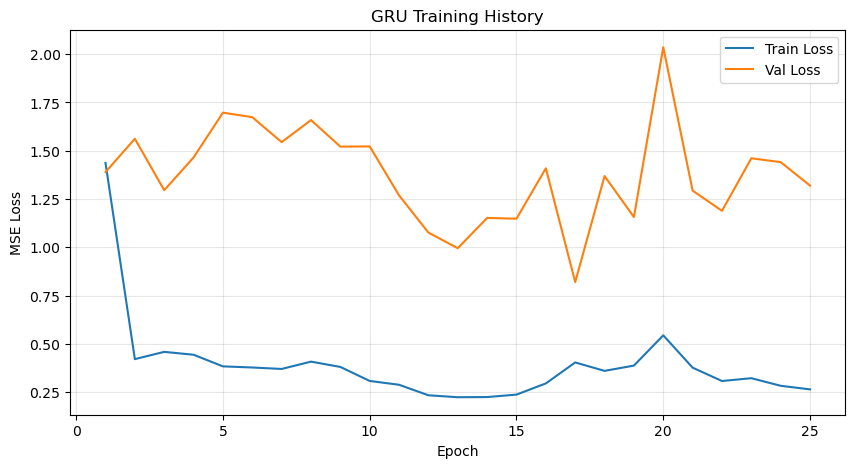

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training History")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

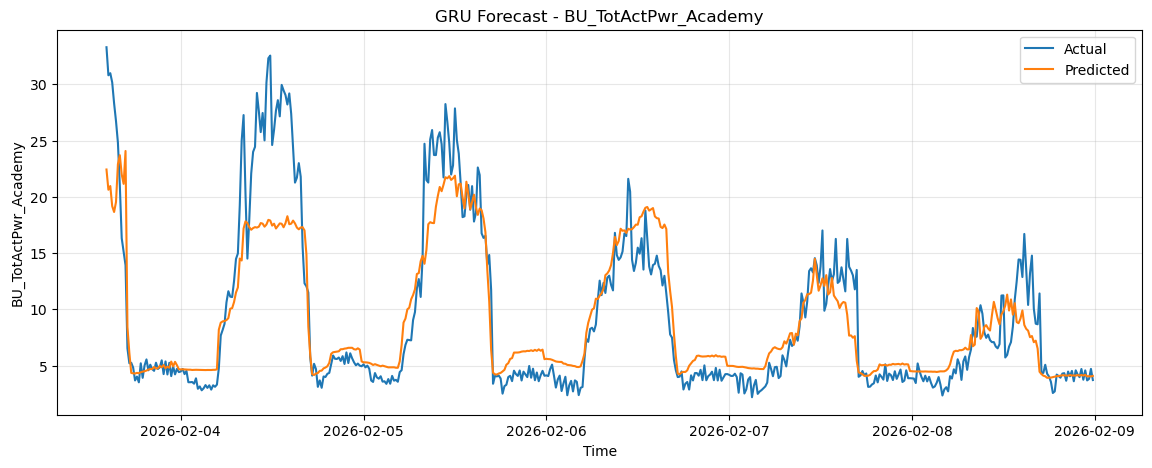

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(pred_df.index, pred_df["y_true"], label="Actual")
plt.plot(pred_df.index, pred_df["y_pred"], label="Predicted")
plt.title(f"GRU Forecast - {target_col}")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()